In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
import numpy.typing as npt
import matplotlib.pyplot as plt
from IPython.display import Video
from scipy.spatial.transform import Rotation

from sklearn.model_selection import train_test_split
from scipy.signal import find_peaks
import seaborn as sb
import itertools


import tensorflow as tf
import tensorflow_hub as hub
from tensorflow import keras

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

#plt.style.use("seaborn-deep")

sb.set_palette("husl",3)
sb.set_style("whitegrid")

2024-04-02 12:23:39.137495: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Manual selection of classes from folders
# !!! For automatic processing all classes go to "Automatic" 

### Function to load data from single folder

In [2]:
def load_and_label_data(file_paths, label):
    """Load data from multiple CSV files and assign a label."""
    data_list = []
    for file_path in file_paths:
        df = pd.read_csv(file_path)
        # The CSV contains 'ax', 'ay', 'az', 'q0', 'q1', 'q2', 'q3'
        df['label'] = label
        data_list.append(df)
    return pd.concat(data_list)

### Load side_raise data

In [169]:
PATH_TO_EXERCISE_FOLDER = "../DMP_9D_ACCEL_Logs/cleaned/side_raise/"

excersise_files = sorted(glob.glob(os.path.join(PATH_TO_EXERCISE_FOLDER, "*.csv")))
print(len(excersise_files))


34


In [170]:
completedf_side_raise = load_and_label_data(excersise_files, 'side_raise')

In [171]:
completedf_side_raise

,timeMs,ax,ay,az,q0,q1,q2,q3,label
0,4175698,4201.0,-2552.0,4161.0,0.837,0.198,-0.174,0.479,side_raise
1,4175724,5033.0,-2700.0,4315.0,0.839,0.186,-0.205,0.468,side_raise
2,4175740,10853.0,-6938.0,8529.0,0.842,0.173,-0.223,0.460,side_raise
3,4175756,7279.0,-4268.0,9501.0,0.844,0.158,-0.233,0.456,side_raise
4,4175772,4305.0,-3212.0,10185.0,0.847,0.145,-0.240,0.452,side_raise
...,...,...,...,...,...,...,...,...,...
844,730969,7714.0,3592.0,556.0,0.451,0.691,-0.278,0.492,side_raise
845,730985,7264.0,3704.0,772.0,0.448,0.691,-0.276,0.495,side_raise
846,731001,7326.0,3376.0,644.0,0.447,0.692,-0.274,0.497,side_raise
847,731017,7702.0,3054.0,88.0,0.446,0.692,-0.272,0.498,side_raise


### Load shoulder_press data

In [203]:
PATH_TO_EXERCISE_FOLDER = "../DMP_9D_ACCEL_Logs/cleaned/shoulder_press/"

excersise_files = sorted(glob.glob(os.path.join(PATH_TO_EXERCISE_FOLDER, "*.csv")))
print(len(excersise_files))

114


In [204]:
completedf_shoulder_press = load_and_label_data(excersise_files, 'shoulder_press')

In [205]:
completedf_shoulder_press

,timeMs,ax,ay,az,q0,q1,q2,q3,label
0,359849,-2411.0,-2335.0,-96.0,0.621,-0.501,0.483,0.360,shoulder_press
1,359865,-2529.0,-2209.0,302.0,0.620,-0.502,0.483,0.362,shoulder_press
2,359884,-3037.0,-2081.0,538.0,0.618,-0.505,0.481,0.362,shoulder_press
3,359900,-2829.0,-2329.0,426.0,0.617,-0.508,0.480,0.361,shoulder_press
4,359916,-2679.0,-1649.0,490.0,0.616,-0.513,0.478,0.358,shoulder_press
...,...,...,...,...,...,...,...,...,...
1096,2044427,-5300.0,2470.0,523.0,0.599,0.641,0.258,-0.403,shoulder_press
1097,2044445,-5060.0,6294.0,-165.0,0.600,0.649,0.242,-0.400,shoulder_press
1098,2044463,-7382.0,8172.0,-675.0,0.606,0.653,0.227,-0.393,shoulder_press
1099,2044481,-5510.0,7266.0,381.0,0.615,0.656,0.208,-0.385,shoulder_press


### Load curl data

In [172]:
PATH_TO_EXERCISE_FOLDER = "../DMP_9D_ACCEL_Logs/cleaned/curl/"

excersise_files = sorted(glob.glob(os.path.join(PATH_TO_EXERCISE_FOLDER, "*.csv")))
print(len(excersise_files))

81


In [173]:
completedf_curl = load_and_label_data(excersise_files, 'curl')

In [174]:
completedf_curl

,timeMs,ax,ay,az,q0,q1,q2,q3,label
0,667522,7970.0,-930.0,886.0,0.685,0.149,-0.658,0.277,curl
1,667539,8152.0,-1186.0,920.0,0.684,0.149,-0.658,0.278,curl
2,667565,8012.0,-1054.0,804.0,0.683,0.148,-0.658,0.279,curl
3,667581,7852.0,-1304.0,744.0,0.683,0.148,-0.658,0.280,curl
4,667597,7828.0,-1568.0,828.0,0.684,0.148,-0.657,0.281,curl
...,...,...,...,...,...,...,...,...,...
1047,6448388,7997.0,5335.0,-461.0,0.017,-0.676,-0.121,-0.727,curl
1048,6448405,7939.0,5579.0,-395.0,0.013,-0.676,-0.118,-0.727,curl
1049,6448422,7571.0,4633.0,-33.0,0.008,-0.677,-0.116,-0.727,curl
1050,6448439,7765.0,4723.0,-373.0,0.001,-0.678,-0.116,-0.726,curl


### Load non_exercise data

In [175]:
PATH_TO_EXERCISE_FOLDER = "../DMP_9D_ACCEL_Logs/cleaned/non_exersice/"

non_excersise_files = sorted(glob.glob(os.path.join(PATH_TO_EXERCISE_FOLDER, "*.csv")))
print(len(non_excersise_files))

299


In [176]:
completedf_non_exersice = load_and_label_data(non_excersise_files, 'non_exersice')

In [177]:
completedf_non_exersice

,timeMs,ax,ay,az,q0,q1,q2,q3,label
0,950627,738.0,7735.0,2804.0,0.817,0.566,0.020,0.108,non_exersice
1,950643,1406.0,7047.0,4612.0,0.818,0.565,0.019,0.106,non_exersice
2,950659,630.0,6429.0,3960.0,0.819,0.563,0.018,0.106,non_exersice
3,950675,1458.0,5841.0,4014.0,0.819,0.564,0.017,0.106,non_exersice
4,950701,1086.0,6679.0,3656.0,0.817,0.566,0.017,0.106,non_exersice
...,...,...,...,...,...,...,...,...,...
843,4175617,1161.0,-1132.0,3283.0,0.793,0.215,-0.040,0.569,non_exersice
844,4175633,1991.0,-1078.0,3789.0,0.807,0.216,-0.062,0.546,non_exersice
845,4175649,2987.0,-724.0,3839.0,0.818,0.218,-0.086,0.525,non_exersice
846,4175665,3931.0,-902.0,3891.0,0.827,0.215,-0.113,0.507,non_exersice


### Concatenate into one dataframe

In [206]:
#df_concatenated = pd.concat([completedf_barbell_bench_press, completedf_shoulder_press, completedf_curl, completedf_non_exersice_press], ignore_index=True)
#df_concatenated = pd.concat([completedf_non_exersice, completedf_curl, completedf_side_raise], ignore_index=True)

df_concatenated = pd.concat([completedf_non_exersice, completedf_curl, completedf_side_raise, completedf_shoulder_press], ignore_index=True)

In [207]:
df_concatenated

,timeMs,ax,ay,az,q0,q1,q2,q3,label
0,950627,738.0,7735.0,2804.0,0.817,0.566,0.020,0.108,non_exersice
1,950643,1406.0,7047.0,4612.0,0.818,0.565,0.019,0.106,non_exersice
2,950659,630.0,6429.0,3960.0,0.819,0.563,0.018,0.106,non_exersice
3,950675,1458.0,5841.0,4014.0,0.819,0.564,0.017,0.106,non_exersice
4,950701,1086.0,6679.0,3656.0,0.817,0.566,0.017,0.106,non_exersice
...,...,...,...,...,...,...,...,...,...
477505,2044427,-5300.0,2470.0,523.0,0.599,0.641,0.258,-0.403,shoulder_press
477506,2044445,-5060.0,6294.0,-165.0,0.600,0.649,0.242,-0.400,shoulder_press
477507,2044463,-7382.0,8172.0,-675.0,0.606,0.653,0.227,-0.393,shoulder_press
477508,2044481,-5510.0,7266.0,381.0,0.615,0.656,0.208,-0.385,shoulder_press


# Automatic dataset processing (skip if need Manual selection)

## Load all data in loop

In [40]:
def load_all_data(base_folder):
    """
    Load and label data from all exercise folders within a base folder.
    
    Parameters:
    - base_folder: The path to the base folder containing exercise subfolders.
    
    Returns:
    - A pandas DataFrame containing all data, labeled by exercise.
    """
    all_data_frames = []
    # List all subdirectories in the base folder
    for folder_name in os.listdir(base_folder):
        folder_path = os.path.join(base_folder, folder_name)
        if os.path.isdir(folder_path):
            exercise_files = sorted(glob.glob(os.path.join(folder_path, "*.csv")))
            # Use the folder name as the label
            df_labeled = load_and_label_data(exercise_files, folder_name)
            all_data_frames.append(df_labeled)
    
    # Concatenate all DataFrames, ignoring index to reset it in the final DataFrame
    df_concatenated = pd.concat(all_data_frames, ignore_index=True)
    return df_concatenated

In [41]:
BASE_FOLDER = "../DMP_9D_ACCEL_Logs/cleaned/"

df_concatenated = load_all_data(BASE_FOLDER)

# Training section
df_concatenated is dataframe build during Manual or Automatic data preparation stages.

Data shape before augmentation

In [208]:
df_concatenated.shape

(477510, 9)

## Augmentation (optional and could be skipped)

In [18]:
def rotate_points(x, y, angle):
    """Rotate points by a given angle around the center."""
    angle_rad = np.radians(angle)
    cos_val = np.cos(angle_rad)
    sin_val = np.sin(angle_rad)
    x_centered, y_centered = x - 0.5, y - 0.5  # Assuming normalized coordinates centered at 0.5
    x_rotated = 0.5 + cos_val * x_centered - sin_val * y_centered
    y_rotated = 0.5 + sin_val * x_centered + cos_val * y_centered
    return x_rotated, y_rotated

def augment_data_with_transformations(df, num_augments=5, noise_level=0.02, scale_var=0.1, rotation_angle=15):
    augment_cols = df.columns[2:-1]  # Excluding timeMs and label from augmentation
    
    # Vectorization of noise and scaling
    noise_x = np.random.normal(loc=0.0, scale=noise_level, size=(len(augment_cols), num_augments))
    noise_y = np.random.normal(loc=0.0, scale=noise_level, size=(len(augment_cols), num_augments))
    scale_factors = 1 + np.random.uniform(-scale_var, scale_var, size=num_augments)
    rotation_angles = np.random.uniform(-rotation_angle, rotation_angle, size=num_augments)

    augmented_data = []
    for idx in range(num_augments):
        augmented_df = df.copy()
        
        # Apply scaling and noise
        augmented_df[augment_cols] *= scale_factors[idx]
        augmented_df[augment_cols] += noise_x[:, idx] + noise_y[:, idx]
        
        # Apply rotation
        # It is assumed that the rotate_points function has been adapted to work with vectors
        x_rotated, y_rotated = rotate_points(augmented_df['ax'], augmented_df['ay'], rotation_angles[idx])
        augmented_df['ax'] = np.clip(x_rotated, 0, 1)
        augmented_df['ay'] = np.clip(y_rotated, 0, 1)
        
        # Apply horizontal flip with a 50% chance
        flip_mask = np.random.rand(len(df)) > 0.5
        augmented_df.loc[flip_mask, augment_cols] = 1 - augmented_df.loc[flip_mask, augment_cols]
        
        augmented_data.append(augmented_df)
        
    # Combine original data with augmented data
    augmented_data_df = pd.concat(augmented_data, ignore_index=True)
    result_df = pd.concat([df] + augmented_data, ignore_index=True)
    
    return result_df

In [21]:
df_concatenated_aug = augment_data_with_transformations(df_concatenated, num_augments=5, noise_level=0.02, scale_var=0.1, rotation_angle=15)

In [24]:
df_concatenated = df_concatenated_aug

(3510270, 9)

### Data shape after augmentation

In [209]:
df_concatenated.shape

(477510, 9)

In [210]:
unique_classes = df_concatenated['label'].unique()
print(unique_classes.shape)

(4,)


In [211]:
unique_classes_counts = df_concatenated['label'].value_counts()
print(unique_classes_counts)

non_exersice      251884
shoulder_press    104586
curl               90085
side_raise         30955
Name: label, dtype: int64


### Split into X, Y

In [212]:
def split_sequences(dataframe, sequence_length, overlap=0):
    """
    Split the dataframe into sequences of a given length with a specified overlap, including all relevant columns.

    :param dataframe: Input dataframe to be split into sequences.
    :param sequence_length: The length of each sequence.
    :param overlap: The number of rows that will overlap between consecutive sequences.
    :return: A tuple of numpy arrays, (X, y), where X is the sequence of features and y is the corresponding label.
    """
    X, y = [], []
    columns_of_interest = ['ax', 'ay', 'az', 'q0', 'q1', 'q2', 'q3']
    
    # Ensure overlap is not larger than sequence_length
    overlap = min(overlap, sequence_length - 1)
    
    # Calculate step size based on sequence_length and overlap
    step_size = sequence_length - overlap
    
    for i in range(0, len(dataframe) - sequence_length + 1, step_size):
        sequence = dataframe.iloc[i:i+sequence_length][columns_of_interest]
        label = dataframe.iloc[i]['label']
        X.append(sequence.values)
        y.append(label)
    
    return np.array(X), np.array(y)

In [213]:
sample_length = 500
#overlap_length = 125
#x, y = split_sequences(df_concatenated, sample_length, overlap_length)
x, y = split_sequences(df_concatenated, sample_length)

In [214]:
len(x), len(y)

(955, 955)

## Check number of samples per class 

In [215]:
from collections import Counter
samples_per_class = Counter(y)
print(samples_per_class)

Counter({'non_exersice': 504, 'shoulder_press': 209, 'curl': 180, 'side_raise': 62})


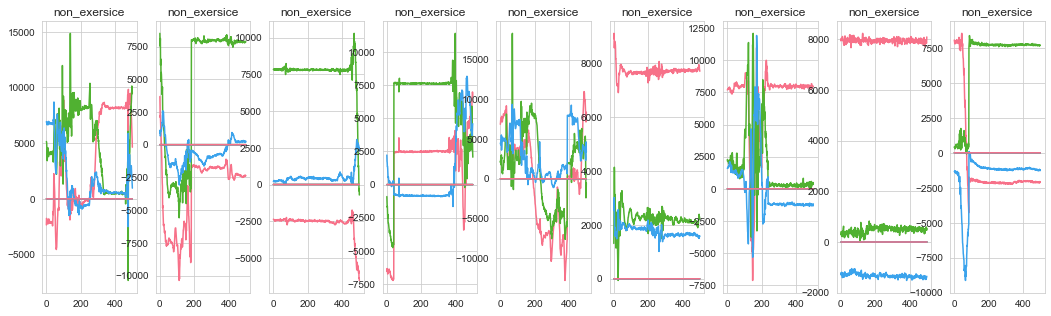

In [216]:
start_id = 300
plt.figure(figsize=(20, 5))
for i in range(1, 10):
    plt.subplot(1, 10, i)
    plt.plot(x[start_id+i])
    plt.title(y[start_id+i])
plt.show()

## Model Train

### Split into train, test, val set

In [217]:
X_train_val, X_val, y_train_val, y_val = train_test_split(x, y, test_size=0.2)
X_train, X_test, y_train, y_test = train_test_split(X_train_val, y_train_val, test_size=0.1)

In [218]:
len(np.unique(y_train))

4

In [219]:
len(np.unique(y_test))

4

In [220]:
y_train.shape, X_train.shape

((687,), (687, 500, 7))

In [221]:
y_test.shape, X_test.shape

((77,), (77, 500, 7))

In [222]:
y_val.shape, X_val.shape

((191,), (191, 500, 7))

### Convert to one hot encoding

In [223]:
class_names = np.unique(y_train)
num_classes = len(np.unique(y_train))
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Convert text labels into numeric identifiers
y_train_encoded = label_encoder.fit_transform(y_train)

# Convert numeric labels into one-hot
y_train_one_hot = to_categorical(y_train_encoded)


# Convert text labels into numeric identifiers
y_val_encoded = label_encoder.fit_transform(y_val)


# Convert numeric labels into one-hot
y_val_one_hot = to_categorical(y_val_encoded)

# Convert text labels into numeric identifiers
y_test_encoded = label_encoder.fit_transform(y_test)

# Convert numeric labels into one-hot
y_test_one_hot = to_categorical(y_test_encoded)

## Debug input for inference testing

In [225]:
np.set_printoptions(threshold=np.inf, linewidth=700)
#X_test[0]
#np.save('model_input.npy', X_test[0])

### Define model

In [226]:
# Define the model
inputs = tf.keras.Input(shape=(sample_length, 7))

# Apply Dense layers to the inputs
layer = keras.layers.Dense(128, activation=tf.nn.relu6)(inputs)
layer = keras.layers.Dropout(0.5)(layer)
layer = keras.layers.Dense(64, activation=tf.nn.relu6)(layer)
layer = keras.layers.Dropout(0.5)(layer)

# Add GlobalAveragePooling1D to reduce dimensionality
layer = keras.layers.GlobalAveragePooling1D()(layer)

# Final layer for classification
outputs = keras.layers.Dense(len(np.unique(y_train)), activation="softmax")(layer)

model = keras.Model(inputs, outputs)
model.summary()

Model: "model_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_7 (InputLayer)        [(None, 500, 7)]          0         
                                                                 
 dense_18 (Dense)            (None, 500, 128)          1024      
                                                                 
 dropout_12 (Dropout)        (None, 500, 128)          0         
                                                                 
 dense_19 (Dense)            (None, 500, 64)           8256      
                                                                 
 dropout_13 (Dropout)        (None, 500, 64)           0         
                                                                 
 global_average_pooling1d_6   (None, 64)               0         
 (GlobalAveragePooling1D)                                        
                                                           

### Train model

In [227]:
adamopt = tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-8)

model.compile(
    optimizer=adamopt,#"adam",
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Add a checkpoint callback to store the checkpoint that has the highest
# validation accuracy.
checkpoint_path = "weights.best.hdf5"
checkpoint = keras.callbacks.ModelCheckpoint(checkpoint_path,
                             monitor='val_accuracy',
                             verbose=1,
                             save_best_only=True,
                             mode='max')
earlystopping = keras.callbacks.EarlyStopping(monitor='val_accuracy', 
                                              patience=50)

# Start training
print(X_train.shape)
history = model.fit(X_train, y_train_one_hot,
                    epochs=200,
                    batch_size=16,
                    validation_data=(X_val, y_val_one_hot),
                    callbacks=[checkpoint, earlystopping],
                    )

(687, 500, 7)
Epoch 1/200
42/43 [============================>.] - ETA: 0s - loss: 0.9805 - accuracy: 0.7649
Epoch 1: val_accuracy improved from -inf to 0.89529, saving model to weights.best.hdf5
43/43 [==============================] - 3s 42ms/step - loss: 0.9620 - accuracy: 0.7700 - val_loss: 0.2304 - val_accuracy: 0.8953
Epoch 2/200
42/43 [============================>.] - ETA: 0s - loss: 0.1801 - accuracy: 0.9360
Epoch 2: val_accuracy improved from 0.89529 to 0.93717, saving model to weights.best.hdf5
43/43 [==============================] - 2s 35ms/step - loss: 0.1769 - accuracy: 0.9374 - val_loss: 0.1399 - val_accuracy: 0.9372
Epoch 3/200
43/43 [==============================] - ETA: 0s - loss: 0.1217 - accuracy: 0.9549
Epoch 3: val_accuracy did not improve from 0.93717
43/43 [==============================] - 1s 31ms/step - loss: 0.1217 - accuracy: 0.9549 - val_loss: 0.1529 - val_accuracy: 0.9372
Epoch 4/200
43/43 [==============================] - ETA: 0s - loss: 0.1048 - accur

Epoch 30/200
43/43 [==============================] - ETA: 0s - loss: 0.0482 - accuracy: 0.9869
Epoch 30: val_accuracy did not improve from 0.96335
43/43 [==============================] - 2s 36ms/step - loss: 0.0482 - accuracy: 0.9869 - val_loss: 0.1543 - val_accuracy: 0.9581
Epoch 31/200
42/43 [============================>.] - ETA: 0s - loss: 0.0430 - accuracy: 0.9866
Epoch 31: val_accuracy did not improve from 0.96335
43/43 [==============================] - 2s 38ms/step - loss: 0.0421 - accuracy: 0.9869 - val_loss: 0.1323 - val_accuracy: 0.9529
Epoch 32/200
42/43 [============================>.] - ETA: 0s - loss: 0.0484 - accuracy: 0.9821
Epoch 32: val_accuracy did not improve from 0.96335
43/43 [==============================] - 2s 37ms/step - loss: 0.0476 - accuracy: 0.9825 - val_loss: 0.1563 - val_accuracy: 0.9581
Epoch 33/200
42/43 [============================>.] - ETA: 0s - loss: 0.0461 - accuracy: 0.9777
Epoch 33: val_accuracy did not improve from 0.96335
43/43 [===========

43/43 [==============================] - 2s 38ms/step - loss: 0.0373 - accuracy: 0.9840 - val_loss: 0.1526 - val_accuracy: 0.9476
Epoch 60/200
42/43 [============================>.] - ETA: 0s - loss: 0.0377 - accuracy: 0.9821
Epoch 60: val_accuracy did not improve from 0.96335
43/43 [==============================] - 1s 33ms/step - loss: 0.0372 - accuracy: 0.9825 - val_loss: 0.1586 - val_accuracy: 0.9529
Epoch 61/200
42/43 [============================>.] - ETA: 0s - loss: 0.0372 - accuracy: 0.9851
Epoch 61: val_accuracy did not improve from 0.96335
43/43 [==============================] - 1s 31ms/step - loss: 0.0367 - accuracy: 0.9854 - val_loss: 0.1246 - val_accuracy: 0.9529


### Plot graph

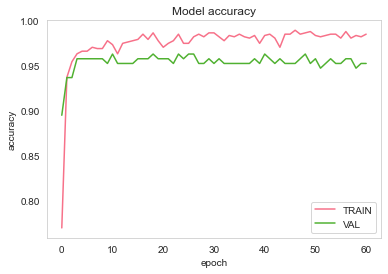

In [228]:
# Visualize the training history to see whether you're overfitting.
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['TRAIN', 'VAL'], loc='lower right')
plt.grid()
plt.show()

### Plot confusion matrix

In [229]:
loss, accuracy = model.evaluate(X_test, y_test_one_hot)

3/3 [==============================] - 0s 38ms/step - loss: 0.2167 - accuracy: 0.9740


3/3 [==============================] - 0s 14ms/step
Confusion matrix, without normalization

Classification Report:
                 precision    recall  f1-score   support

          curl       1.00      1.00      1.00        13
  non_exersice       0.98      0.98      0.98        42
shoulder_press       1.00      1.00      1.00        16
    side_raise       0.83      0.83      0.83         6

      accuracy                           0.97        77
     macro avg       0.95      0.95      0.95        77
  weighted avg       0.97      0.97      0.97        77



/var/folders/c5/xpfx3gxx5d34j23111nbtn000000gn/T/ipykernel_24529/1767718340.py:14: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


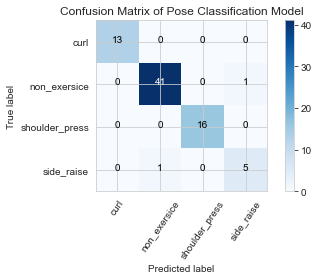

In [230]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
  """Plots the confusion matrix."""
  if normalize:
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    print("Normalized confusion matrix")
  else:
    print('Confusion matrix, without normalization')

  plt.imshow(cm, interpolation='nearest', cmap=cmap)
  plt.title(title)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes, rotation=55)
  plt.yticks(tick_marks, classes)
  fmt = '.2f' if normalize else 'd'
  thresh = cm.max() / 2.
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], fmt),
              horizontalalignment="center",
              color="white" if cm[i, j] > thresh else "black")

  plt.ylabel('True label')
  plt.xlabel('Predicted label')
  plt.tight_layout()

# Classify pose in the TEST dataset using the trained model
y_pred = model.predict(X_test)

# Convert the prediction result to class name
y_pred_label = [class_names[i] for i in np.argmax(y_pred, axis=1)]
y_true_label = [class_names[i] for i in np.argmax(y_test_one_hot, axis=1)]

# Plot the confusion matrix
cm = confusion_matrix(np.argmax(y_test_one_hot, axis=1), np.argmax(y_pred, axis=1))
plot_confusion_matrix(cm,
                      class_names,
                      title ='Confusion Matrix of Pose Classification Model')

# Print the classification report
print('\nClassification Report:\n', classification_report(y_true_label, y_pred_label))

# To be used in inference script. Here print correspondence between class name and ID

In [231]:
mapping = dict(zip(label_encoder.classes_, range(0, len(label_encoder.classes_)+1)))
print(mapping)


{'curl': 0, 'non_exersice': 1, 'shoulder_press': 2, 'side_raise': 3}
